# Notebook 07: Intervention Prioritization and Business Recommendation

This notebook converts the ranked 30-day readmission-risk outputs into an operational intervention-prioritization strategy.

The goals are:

- load the provisional candidate-model and subgroup-review outputs
- validate the existing rank-based outreach thresholds
- summarize encounter-level threshold performance
- distinguish encounter-level evaluation from patient-level outreach
- create a deduplicated patient-level outreach roster
- assign proposed actions by risk tier
- incorporate subgroup-monitoring requirements
- define a controlled top-decile pilot recommendation
- export business-ready prioritization outputs

This notebook does not retrain the model, calibrate predicted scores, or estimate the causal effect of outreach.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)

## 2. Project Paths

In [2]:
def find_project_root(start_path=None):
    """
    Finds the project root by walking upward until the cleaned dataset is found.

    This avoids assuming that the current working directory is exactly the project
    root or the notebooks folder.
    """
    start_path = Path.cwd() if start_path is None else Path(start_path)

    for path in [start_path, *start_path.parents]:
        expected_file = (
            path
            / "data"
            / "processed"
            / "diabetes_readmission_cleaned.csv"
        )

        if expected_file.exists():
            return path

    raise FileNotFoundError(
        "Could not locate project root. Expected to find "
        "'data/processed/diabetes_readmission_cleaned.csv' "
        "in this folder or a parent folder."
    )


PROJECT_ROOT = find_project_root()

OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
MODEL_RESULTS = OUTPUTS / "model_results"
OUTREACH_LISTS = OUTPUTS / "outreach_lists"

for path in [OUTPUTS, FIGURES, MODEL_RESULTS, OUTREACH_LISTS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root detected successfully.")
print("Project folder:", PROJECT_ROOT.name)

Project root detected successfully.
Project folder: 03_risk_stratification_intervention_prioritization


## 3. Load Model, Ranking, and Subgroup Outputs

In [3]:
selected_model_path = MODEL_RESULTS / "selected_candidate_model.csv"
candidate_cv_summary_path = MODEL_RESULTS / "candidate_model_cv_summary.csv"

ranking_with_subgroups_path = (
    MODEL_RESULTS / "test_ranking_with_subgroups.csv"
)

subgroup_flags_path = (
    MODEL_RESULTS / "subgroup_monitoring_flags.csv"
)

threshold_selection_path = (
    MODEL_RESULTS / "subgroup_threshold_selection_summary.csv"
)

risk_tier_source_path = (
    MODEL_RESULTS / "risk_tier_summary.csv"
)

capacity_source_path = (
    MODEL_RESULTS / "outreach_capacity_summary.csv"
)

required_paths = [
    selected_model_path,
    ranking_with_subgroups_path,
    subgroup_flags_path,
    threshold_selection_path
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

assert not missing_paths, f"Missing required files: {missing_paths}"

selected_model = pd.read_csv(
    selected_model_path,
    low_memory=False
)

ranking_with_subgroups = pd.read_csv(
    ranking_with_subgroups_path,
    low_memory=False
)

subgroup_monitoring_flags = pd.read_csv(
    subgroup_flags_path,
    low_memory=False
)

threshold_selection_source = pd.read_csv(
    threshold_selection_path,
    low_memory=False
)

candidate_cv_summary = (
    pd.read_csv(candidate_cv_summary_path, low_memory=False)
    if candidate_cv_summary_path.exists()
    else pd.DataFrame()
)

print("Selected model output:", selected_model.shape)
print("Ranked test encounters:", ranking_with_subgroups.shape)
print("Subgroup monitoring rows:", subgroup_monitoring_flags.shape)
print("Threshold summary rows:", threshold_selection_source.shape)

Selected model output: (1, 7)
Ranked test encounters: (20153, 13)
Subgroup monitoring rows: (19, 19)
Threshold summary rows: (3, 5)


In [4]:
display(selected_model)
display(threshold_selection_source.round(4))
display(ranking_with_subgroups.head())

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Gradient Boosting,0.893267,0.5,0.000465,0.000929,0.66626,0.206588


,threshold,rank_cutoff,selected_encounters,selection_rate,observed_readmission_rate
0,Top 5%,1008,1008,0.05,0.3006
1,Top 10%,2016,2016,0.10,0.2579
2,Top 20%,4031,4031,0.20,0.2039


,encounter_id,patient_nbr,actual_readmitted_30d,predicted_readmission_risk,risk_rank,risk_percentile,risk_tier,age,race,gender,top_5_selected,top_10_selected,top_20_selected
0,341998334,88227540,1,0.519773,1,0.000050,Very High Risk - Top 5%,[40-50),AfricanAmerican,Female,1,1,1
1,362647880,88227540,0,0.516862,2,0.000099,Very High Risk - Top 5%,[40-50),AfricanAmerican,Female,1,1,1
2,220315764,87452694,1,0.499352,3,0.000149,Very High Risk - Top 5%,[70-80),Caucasian,Female,1,1,1
3,302587472,88227540,1,0.495687,4,0.000198,Very High Risk - Top 5%,[40-50),AfricanAmerican,Female,1,1,1
4,189144708,42941232,1,0.484275,5,0.000248,Very High Risk - Top 5%,[70-80),Caucasian,Male,1,1,1


### Interpretation

Notebook 07 uses the ranked and subgroup-reviewed test encounters created in the previous notebooks.

The model is not retrained here.

The selected candidate model remains provisional because:

- model families were compared using fixed parameters
- final hyperparameter tuning has not been completed
- probability calibration has not been completed
- external validation has not been completed

The predicted score is used for ranking. It should not yet be interpreted as a calibrated absolute readmission probability.

## 4. Validate Final Ranked Encounter Data

In [5]:
required_ranking_columns = [
    "encounter_id",
    "patient_nbr",
    "actual_readmitted_30d",
    "predicted_readmission_risk",
    "risk_rank",
    "risk_percentile",
    "risk_tier",
    "age",
    "race",
    "gender",
    "top_5_selected",
    "top_10_selected",
    "top_20_selected"
]

missing_columns = [
    col for col in required_ranking_columns
    if col not in ranking_with_subgroups.columns
]

assert not missing_columns, (
    f"Missing required ranking columns: {missing_columns}"
)

assert ranking_with_subgroups["encounter_id"].is_unique, (
    "encounter_id must be unique in the ranked encounter dataset."
)

assert set(
    ranking_with_subgroups[
        "actual_readmitted_30d"
    ].dropna().unique()
) <= {0, 1}, "Actual target must be binary."

assert ranking_with_subgroups[
    "predicted_readmission_risk"
].between(0, 1).all(), (
    "Predicted model scores must be between 0 and 1."
)

assert ranking_with_subgroups[
    "risk_percentile"
].between(0, 1).all(), (
    "Risk percentile must be between 0 and 1."
)

print("Ranked encounter validation checks passed.")

Ranked encounter validation checks passed.


In [6]:
n_test = len(ranking_with_subgroups)

expected_cutoffs = {
    "top_5_selected": int(np.ceil(n_test * 0.05)),
    "top_10_selected": int(np.ceil(n_test * 0.10)),
    "top_20_selected": int(np.ceil(n_test * 0.20))
}

for selection_col, expected_count in expected_cutoffs.items():
    actual_count = int(
        ranking_with_subgroups[selection_col].sum()
    )

    assert actual_count == expected_count, (
        f"{selection_col} contains {actual_count} rows; "
        f"expected {expected_count}."
    )

print("Rank-based selection counts validated.")
print(expected_cutoffs)

Rank-based selection counts validated.
{'top_5_selected': 1008, 'top_10_selected': 2016, 'top_20_selected': 4031}


In [7]:
for selection_col, expected_count in expected_cutoffs.items():
    selected_rows = ranking_with_subgroups[
        ranking_with_subgroups[selection_col] == 1
    ]

    not_selected_rows = ranking_with_subgroups[
        ranking_with_subgroups[selection_col] == 0
    ]

    assert selected_rows["risk_rank"].max() <= expected_count

    if len(not_selected_rows) > 0:
        assert not_selected_rows["risk_rank"].min() > expected_count

print("Selection flags align with risk-rank cutoffs.")

Selection flags align with risk-rank cutoffs.


### Interpretation

Notebook 06 uses exact rank-based cutoffs.

This is important because rank-based selection keeps outreach-group sizes consistent even when multiple encounters have similar model scores.

Notebook 07 therefore reuses the existing selection flags rather than recreating thresholds from rounded percentiles or fixed score cutoffs.

## 5. Provisional Candidate Model Context

In [8]:
selected_model_name = (
    selected_model["model"].iloc[0]
    if "model" in selected_model.columns
    else "Selected Candidate Model"
)

print("Provisional candidate model:", selected_model_name)

display(selected_model.round(4))

if not candidate_cv_summary.empty:
    if "model" in candidate_cv_summary.columns:
        selected_cv_summary = candidate_cv_summary[
            candidate_cv_summary["model"] == selected_model_name
        ].copy()
    else:
        selected_cv_summary = candidate_cv_summary.copy()

    display(selected_cv_summary.round(4))

Provisional candidate model: Gradient Boosting


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Gradient Boosting,0.8933,0.5,0.0005,0.0009,0.6663,0.2066


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,top_10_lift_mean,top_10_lift_std
0,Gradient Boosting,0.6724,0.0049,0.2227,0.0076,2.3466,0.0599


### Interpretation

Gradient Boosting is the provisional candidate model from the fixed-parameter comparison.

The default `0.50` classification threshold produces very low positive-class recall and is not the operational decision rule used in this project.

The operational strategy uses ranked top-k groups instead:

- Top 5%
- Top 10%
- Top 20%

Model selection and intervention planning should therefore emphasize ranking performance, lift, and readmission capture rather than default-threshold accuracy.

## 6. Recalculate Final Encounter-Level Threshold Performance

In [9]:
baseline_readmission_rate = ranking_with_subgroups[
    "actual_readmitted_30d"
].mean()

total_readmissions = int(
    ranking_with_subgroups[
        "actual_readmitted_30d"
    ].sum()
)

print(
    f"Baseline test-set readmission rate: "
    f"{baseline_readmission_rate:.2%}"
)

print("Total test-set readmissions:", total_readmissions)

Baseline test-set readmission rate: 10.67%
Total test-set readmissions: 2151


In [10]:
def summarize_existing_threshold(
    data,
    selection_col,
    threshold_label
):
    """
    Summarizes an existing rank-based outreach threshold.

    The function reuses selection flags created in Notebook 06 rather than
    independently recreating threshold membership.
    """
    selected = data[
        data[selection_col] == 1
    ].copy()

    selected_readmissions = int(
        selected["actual_readmitted_30d"].sum()
    )

    selected_readmission_rate = (
        selected["actual_readmitted_30d"].mean()
    )

    return {
        "threshold": threshold_label,
        "selection_column": selection_col,
        "selected_encounters": len(selected),
        "selected_unique_patients": (
            selected["patient_nbr"].nunique()
        ),
        "selected_readmissions": selected_readmissions,
        "selected_readmission_rate": (
            selected_readmission_rate
        ),
        "baseline_readmission_rate": (
            baseline_readmission_rate
        ),
        "lift_vs_baseline": (
            selected_readmission_rate
            / baseline_readmission_rate
            if baseline_readmission_rate > 0
            else np.nan
        ),
        "percent_of_readmissions_captured": (
            selected_readmissions
            / total_readmissions
            if total_readmissions > 0
            else np.nan
        )
    }

In [11]:
final_threshold_summary = pd.DataFrame([
    summarize_existing_threshold(
        ranking_with_subgroups,
        "top_5_selected",
        "Top 5%"
    ),
    summarize_existing_threshold(
        ranking_with_subgroups,
        "top_10_selected",
        "Top 10%"
    ),
    summarize_existing_threshold(
        ranking_with_subgroups,
        "top_20_selected",
        "Top 20%"
    )
])

display(final_threshold_summary.round(4))

,threshold,selection_column,selected_encounters,selected_unique_patients,selected_readmissions,selected_readmission_rate,baseline_readmission_rate,lift_vs_baseline,percent_of_readmissions_captured
0,Top 5%,top_5_selected,1008,631,303,0.3006,0.1067,2.8163,0.1409
1,Top 10%,top_10_selected,2016,1240,520,0.2579,0.1067,2.4166,0.2417
2,Top 20%,top_20_selected,4031,2468,822,0.2039,0.1067,1.9105,0.3821


In [12]:
threshold_validation = final_threshold_summary.merge(
    threshold_selection_source[
        [
            "threshold",
            "selected_encounters",
            "observed_readmission_rate"
        ]
    ],
    on="threshold",
    how="left",
    suffixes=("_recalculated", "_notebook_06")
)

threshold_validation["count_matches"] = (
    threshold_validation[
        "selected_encounters_recalculated"
    ]
    ==
    threshold_validation[
        "selected_encounters_notebook_06"
    ]
)

threshold_validation["rate_difference"] = (
    threshold_validation[
        "selected_readmission_rate"
    ]
    -
    threshold_validation[
        "observed_readmission_rate"
    ]
)

assert threshold_validation["count_matches"].all()
assert np.allclose(
    threshold_validation["rate_difference"],
    0,
    atol=1e-10
)

display(threshold_validation.round(4))

,threshold,selection_column,selected_encounters_recalculated,selected_unique_patients,selected_readmissions,selected_readmission_rate,baseline_readmission_rate,lift_vs_baseline,percent_of_readmissions_captured,selected_encounters_notebook_06,observed_readmission_rate,count_matches,rate_difference
0,Top 5%,top_5_selected,1008,631,303,0.3006,0.1067,2.8163,0.1409,1008,0.3006,True,0.0
1,Top 10%,top_10_selected,2016,1240,520,0.2579,0.1067,2.4166,0.2417,2016,0.2579,True,0.0
2,Top 20%,top_20_selected,4031,2468,822,0.2039,0.1067,1.9105,0.3821,4031,0.2039,True,0.0


### Interpretation

The threshold results match Notebook 06.

The current retrospective results show a clear tradeoff:

- Top 5% has the greatest risk concentration
- Top 10% balances concentration and outreach volume
- Top 20% captures more readmissions but with lower concentration

The top 10% remains the provisional pilot threshold.

## 7. Visualize Outreach Capacity Tradeoffs

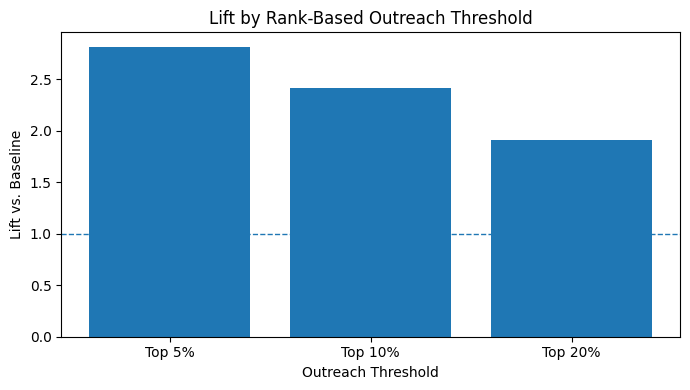

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(
    final_threshold_summary["threshold"],
    final_threshold_summary["lift_vs_baseline"]
)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Lift by Rank-Based Outreach Threshold")
plt.xlabel("Outreach Threshold")
plt.ylabel("Lift vs. Baseline")
plt.tight_layout()

plt.savefig(
    FIGURES / "final_lift_by_outreach_threshold.png",
    dpi=300
)
plt.show()

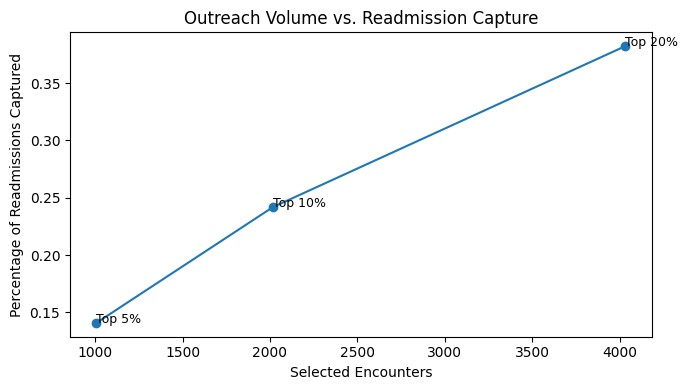

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(
    final_threshold_summary["selected_encounters"],
    final_threshold_summary[
        "percent_of_readmissions_captured"
    ],
    marker="o"
)

for _, row in final_threshold_summary.iterrows():
    plt.annotate(
        row["threshold"],
        (
            row["selected_encounters"],
            row["percent_of_readmissions_captured"]
        ),
        fontsize=9
    )

plt.title("Outreach Volume vs. Readmission Capture")
plt.xlabel("Selected Encounters")
plt.ylabel("Percentage of Readmissions Captured")
plt.tight_layout()

plt.savefig(
    FIGURES / "final_outreach_volume_vs_readmission_capture.png",
    dpi=300
)
plt.show()

### Interpretation

Smaller outreach groups produce stronger concentration but reach fewer total readmissions.

Larger outreach groups capture more readmissions but require more capacity and produce lower lift.

The recommended threshold is therefore an operational tradeoff, not a universal model cutoff.

## 8. Final Risk Tier Summary

In [15]:
risk_tier_order = [
    "Very High Risk - Top 5%",
    "High Risk - 5% to 10%",
    "Moderate Risk - 10% to 25%",
    "Lower Risk - Bottom 75%"
]

final_ranking = ranking_with_subgroups.copy()

final_ranking["risk_tier"] = pd.Categorical(
    final_ranking["risk_tier"],
    categories=risk_tier_order,
    ordered=True
)

final_ranking = final_ranking.sort_values(
    "risk_rank"
).reset_index(drop=True)

final_risk_tier_summary = (
    final_ranking
    .groupby("risk_tier", observed=False)
    .agg(
        encounter_count=("encounter_id", "size"),
        unique_patient_count=("patient_nbr", "nunique"),
        readmission_count=(
            "actual_readmitted_30d",
            "sum"
        ),
        avg_model_score=(
            "predicted_readmission_risk",
            "mean"
        ),
        observed_readmission_rate=(
            "actual_readmitted_30d",
            "mean"
        )
    )
    .reset_index()
)

final_risk_tier_summary[
    "baseline_readmission_rate"
] = baseline_readmission_rate

final_risk_tier_summary["lift_vs_baseline"] = (
    final_risk_tier_summary[
        "observed_readmission_rate"
    ]
    /
    final_risk_tier_summary[
        "baseline_readmission_rate"
    ]
)

display(final_risk_tier_summary.round(4))

,risk_tier,encounter_count,unique_patient_count,readmission_count,avg_model_score,observed_readmission_rate,baseline_readmission_rate,lift_vs_baseline
0,Very High Risk - Top 5%,1008,631,303,0.2868,0.3006,0.1067,2.8163
1,High Risk - 5% to 10%,1008,822,217,0.1978,0.2153,0.1067,2.0170
2,Moderate Risk - 10% to 25%,3023,2423,443,0.1534,0.1465,0.1067,1.3730
3,Lower Risk - Bottom 75%,15114,12857,1188,0.0860,0.0786,0.1067,0.7364


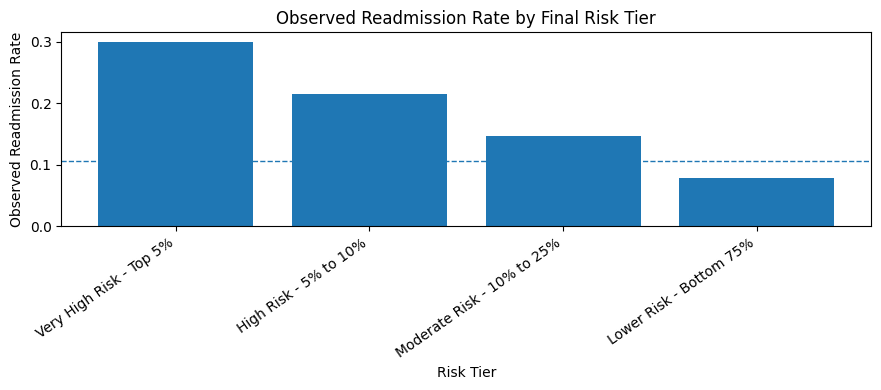

In [16]:
plt.figure(figsize=(9, 4))
plt.bar(
    final_risk_tier_summary["risk_tier"].astype(str),
    final_risk_tier_summary[
        "observed_readmission_rate"
    ]
)
plt.axhline(
    baseline_readmission_rate,
    linestyle="--",
    linewidth=1
)
plt.title("Observed Readmission Rate by Final Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Observed Readmission Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES / "final_readmission_rate_by_risk_tier.png",
    dpi=300
)
plt.show()

### Interpretation

Risk tiers are capacity-based ranking groups.

The average model score is shown for relative comparison only.

Because probability calibration has not been completed, it should not be interpreted as the subgroup or tier's true absolute readmission probability.

## 9. Encounter-Level vs. Patient-Level Outreach

In [17]:
top_10_encounters = (
    final_ranking[
        final_ranking["top_10_selected"] == 1
    ]
    .sort_values("risk_rank")
    .copy()
)

encounter_patient_summary = pd.DataFrame({
    "metric": [
        "top_10_selected_encounters",
        "top_10_unique_patients",
        "duplicate_encounter_rows",
        "patients_with_multiple_selected_encounters"
    ],
    "value": [
        len(top_10_encounters),
        top_10_encounters["patient_nbr"].nunique(),
        (
            len(top_10_encounters)
            -
            top_10_encounters["patient_nbr"].nunique()
        ),
        (
            top_10_encounters["patient_nbr"]
            .value_counts()
            .gt(1)
            .sum()
        )
    ]
})

display(encounter_patient_summary)

,metric,value
0,top_10_selected_encounters,2016
1,top_10_unique_patients,1240
2,duplicate_encounter_rows,776
3,patients_with_multiple_selected_encounters,341


In [18]:
unique_test_patients = final_ranking["patient_nbr"].nunique()
selected_unique_patients = top_10_encounters["patient_nbr"].nunique()

patient_selection_rate = (
    selected_unique_patients / unique_test_patients
)

print("Unique test patients:", f"{unique_test_patients:,}")
print(
    "Unique patients derived from Top 10% encounter threshold:",
    f"{selected_unique_patients:,}"
)
print(
    "Patient-level selection rate after deduplication:",
    f"{patient_selection_rate:.2%}"
)

Unique test patients: 14,304
Unique patients derived from Top 10% encounter threshold: 1,240
Patient-level selection rate after deduplication: 8.67%


### Interpretation

The model predicts encounter-level risk, so retrospective performance is evaluated at the encounter level.

Care management outreach is generally patient-level.

If the same patient has multiple selected encounters, an operational list should not create duplicate outreach assignments without review.

Notebook 07 therefore creates:

1. An encounter-level retrospective evaluation list
2. A patient-level deduplicated operational outreach list

The Top 10% threshold is defined using encounter-level rankings. After selected encounters are deduplicated, the resulting operational roster contains 1,240 unique patients, representing approximately 8.67% of unique patients in the test population.

This is therefore not a Top 10% patient-level threshold. It is a patient roster derived from the Top 10% encounter-level threshold.

A future implementation could instead aggregate each patient’s current eligible encounters first and then select a fixed percentage of unique patients if staffing capacity is defined directly at the patient level.

## 10. Create Patient-Level Priority List

In [19]:
# Sort first so "first" represents the highest-ranked encounter for each patient.
top_10_sorted = top_10_encounters.sort_values(
    ["risk_rank", "encounter_id"]
)

top_10_patient_retrospective = (
    top_10_sorted
    .groupby("patient_nbr", as_index=False)
    .agg(
        priority_encounter_id=("encounter_id", "first"),
        highest_model_score=(
            "predicted_readmission_risk",
            "first"
        ),
        best_risk_rank=("risk_rank", "min"),
        best_risk_percentile=("risk_percentile", "min"),
        risk_tier=("risk_tier", "first"),
        qualifying_encounter_count=(
            "encounter_id",
            "size"
        ),
        any_observed_readmission=(
            "actual_readmitted_30d",
            "max"
        ),
        age_group=("age", "first"),
        race=("race", "first"),
        gender=("gender", "first")
    )
)

top_10_patient_retrospective = (
    top_10_patient_retrospective
    .sort_values("best_risk_rank")
    .reset_index(drop=True)
)

display(top_10_patient_retrospective.head(20))

,patient_nbr,priority_encounter_id,highest_model_score,best_risk_rank,best_risk_percentile,risk_tier,qualifying_encounter_count,any_observed_readmission,age_group,race,gender
0,88227540,341998334,0.519773,1,0.000050,Very High Risk - Top 5%,21,1,[40-50),AfricanAmerican,Female
1,87452694,220315764,0.499352,3,0.000149,Very High Risk - Top 5%,1,1,[70-80),Caucasian,Female
2,42941232,189144708,0.484275,5,0.000248,Very High Risk - Top 5%,7,1,[70-80),Caucasian,Male
3,93205692,194005518,0.483846,6,0.000298,Very High Risk - Top 5%,8,1,[40-50),Caucasian,Male
4,92118987,100478628,0.483218,7,0.000347,Very High Risk - Top 5%,2,1,[60-70),Caucasian,Male
5,79729218,117387726,0.481135,8,0.000397,Very High Risk - Top 5%,2,1,[70-80),Caucasian,Male
6,91751121,166259388,0.478712,9,0.000447,Very High Risk - Top 5%,14,1,[60-70),Caucasian,Male
7,81169038,164678202,0.476535,10,0.000496,Very High Risk - Top 5%,2,1,[80-90),AfricanAmerican,Female
8,1743804,141822996,0.471886,11,0.000546,Very High Risk - Top 5%,2,1,[30-40),Caucasian,Male
9,23838849,120136542,0.464759,13,0.000645,Very High Risk - Top 5%,9,1,[70-80),AfricanAmerican,Male


In [20]:
top_10_patient_operational = (
    top_10_patient_retrospective[
        [
            "patient_nbr",
            "priority_encounter_id",
            "highest_model_score",
            "best_risk_rank",
            "best_risk_percentile",
            "risk_tier",
            "qualifying_encounter_count",
            "age_group"
        ]
    ]
    .copy()
)

display(top_10_patient_operational.head(20))

,patient_nbr,priority_encounter_id,highest_model_score,best_risk_rank,best_risk_percentile,risk_tier,qualifying_encounter_count,age_group
0,88227540,341998334,0.519773,1,0.000050,Very High Risk - Top 5%,21,[40-50)
1,87452694,220315764,0.499352,3,0.000149,Very High Risk - Top 5%,1,[70-80)
2,42941232,189144708,0.484275,5,0.000248,Very High Risk - Top 5%,7,[70-80)
3,93205692,194005518,0.483846,6,0.000298,Very High Risk - Top 5%,8,[40-50)
4,92118987,100478628,0.483218,7,0.000347,Very High Risk - Top 5%,2,[60-70)
5,79729218,117387726,0.481135,8,0.000397,Very High Risk - Top 5%,2,[70-80)
6,91751121,166259388,0.478712,9,0.000447,Very High Risk - Top 5%,14,[60-70)
7,81169038,164678202,0.476535,10,0.000496,Very High Risk - Top 5%,2,[80-90)
8,1743804,141822996,0.471886,11,0.000546,Very High Risk - Top 5%,2,[30-40)
9,23838849,120136542,0.464759,13,0.000645,Very High Risk - Top 5%,9,[70-80)


### Interpretation

The operational list excludes:

- `actual_readmitted_30d`
- retrospective true/false-positive indicators
- race and gender monitoring fields

The future readmission outcome would not be available at prediction time.

Race and gender remain available in separate subgroup-monitoring outputs rather than the core outreach roster.

## 11. Assign Proposed Operational Actions

In [21]:
action_map = {
    "Very High Risk - Top 5%": (
        "Priority review and first outreach attempt"
    ),
    "High Risk - 5% to 10%": (
        "Standard pilot outreach after Very High Risk group"
    ),
    "Moderate Risk - 10% to 25%": (
        "Monitor or include if additional capacity is available"
    ),
    "Lower Risk - Bottom 75%": (
        "Usual workflow without model-prioritized outreach"
    )
}

top_10_patient_operational["proposed_action"] = (
    top_10_patient_operational[
        "risk_tier"
    ]
    .astype(str)
    .map(action_map)
)

display(
    top_10_patient_operational.head(20)
)

,patient_nbr,priority_encounter_id,highest_model_score,best_risk_rank,best_risk_percentile,risk_tier,qualifying_encounter_count,age_group,proposed_action
0,88227540,341998334,0.519773,1,0.000050,Very High Risk - Top 5%,21,[40-50),Priority review and first outreach attempt
1,87452694,220315764,0.499352,3,0.000149,Very High Risk - Top 5%,1,[70-80),Priority review and first outreach attempt
2,42941232,189144708,0.484275,5,0.000248,Very High Risk - Top 5%,7,[70-80),Priority review and first outreach attempt
3,93205692,194005518,0.483846,6,0.000298,Very High Risk - Top 5%,8,[40-50),Priority review and first outreach attempt
4,92118987,100478628,0.483218,7,0.000347,Very High Risk - Top 5%,2,[60-70),Priority review and first outreach attempt
5,79729218,117387726,0.481135,8,0.000397,Very High Risk - Top 5%,2,[70-80),Priority review and first outreach attempt
6,91751121,166259388,0.478712,9,0.000447,Very High Risk - Top 5%,14,[60-70),Priority review and first outreach attempt
7,81169038,164678202,0.476535,10,0.000496,Very High Risk - Top 5%,2,[80-90),Priority review and first outreach attempt
8,1743804,141822996,0.471886,11,0.000546,Very High Risk - Top 5%,2,[30-40),Priority review and first outreach attempt
9,23838849,120136542,0.464759,13,0.000645,Very High Risk - Top 5%,9,[70-80),Priority review and first outreach attempt


In [22]:
# Validate that the prototype outreach roster is patient-level
# and does not contain retrospective outcomes or monitoring-only fields.
assert top_10_patient_operational["patient_nbr"].is_unique, (
    "Operational outreach roster contains duplicate patients."
)

forbidden_operational_columns = {
    "actual_readmitted_30d",
    "any_observed_readmission",
    "race",
    "gender"
}

unexpected_operational_columns = (
    forbidden_operational_columns
    .intersection(top_10_patient_operational.columns)
)

assert not unexpected_operational_columns, (
    "Operational outreach roster contains prohibited fields: "
    f"{sorted(unexpected_operational_columns)}"
)

assert top_10_patient_operational["proposed_action"].notna().all(), (
    "One or more selected patients are missing a proposed action."
)

print("Prototype patient-level outreach roster validation passed.")

Prototype patient-level outreach roster validation passed.


### Interpretation

These action categories are portfolio recommendations, not clinical orders.

A real workflow would still require:

- eligibility review
- discharge-status review
- existing care-management enrollment checks
- contact-preference review
- clinical or operational override rules

## 12. Incorporate Subgroup Monitoring Findings

In [23]:
subgroup_review_priority = (
    subgroup_monitoring_flags
    .copy()
)

subgroup_review_priority[
    "absolute_selection_rate_difference"
] = subgroup_review_priority[
    "selection_rate_diff_vs_overall"
].abs()

subgroup_review_priority[
    "absolute_recall_difference"
] = subgroup_review_priority[
    "recall_diff_vs_overall"
].abs()

subgroup_review_priority = (
    subgroup_review_priority
    .sort_values(
        [
            "small_sample_flag",
            "absolute_recall_difference",
            "absolute_selection_rate_difference"
        ],
        ascending=[False, False, False]
    )
)

display(
    subgroup_review_priority[
        [
            "subgroup_variable",
            "subgroup_value",
            "encounter_count",
            "readmission_rate",
            "selection_rate",
            "recall",
            "false_negative_rate",
            "small_sample_flag",
            "selection_rate_diff_vs_overall",
            "recall_diff_vs_overall"
        ]
    ].round(4)
)

,subgroup_variable,subgroup_value,encounter_count,readmission_rate,selection_rate,recall,false_negative_rate,small_sample_flag,selection_rate_diff_vs_overall,recall_diff_vs_overall
0,age,[0-10),38,0.0526,0.0000,0.0000,1.0000,1,-0.1000,-0.2417
18,gender,Unknown/Invalid,2,0.0000,0.5000,NaN,NaN,1,0.4000,NaN
12,race,Unknown,410,0.0512,0.0463,0.0476,0.9524,0,-0.0537,-0.1941
2,age,[20-30),285,0.0807,0.1158,0.0870,0.9130,0,0.0158,-0.1548
9,age,[90-100),528,0.0852,0.0625,0.0889,0.9111,0,-0.0375,-0.1529
3,age,[30-40),804,0.1231,0.1667,0.3535,0.6465,0,0.0666,0.1118
4,age,[40-50),1893,0.1020,0.1067,0.3212,0.6788,0,0.0067,0.0795
1,age,[10-20),137,0.0365,0.0949,0.2000,0.8000,0,-0.0051,-0.0417
11,race,AfricanAmerican,3847,0.1105,0.1133,0.2800,0.7200,0,0.0133,0.0383
14,race,Other,289,0.1003,0.0865,0.2759,0.7241,0,-0.0135,0.0341


### Interpretation

The attached subgroup review identified meaningful variation and very small groups.

Examples requiring cautious interpretation include:

- age `[0-10)` with a small encounter count
- `Unknown/Invalid` gender with an extremely small sample
- race categories with substantially smaller samples than the largest groups
- age groups with visibly different selection and recall rates

These are monitoring findings, not proof of unfairness.

In [24]:
subgroup_monitoring_requirements = pd.DataFrame([
    {
        "monitoring_area": "Selection",
        "metric": "Selection rate by subgroup",
        "purpose": (
            "Identify differences in who enters "
            "the outreach population"
        ),
        "recommended_frequency": "Each scoring cycle"
    },
    {
        "monitoring_area": "Outreach",
        "metric": "Outreach completion rate by subgroup",
        "purpose": (
            "Check whether selected groups receive "
            "comparable outreach"
        ),
        "recommended_frequency": "Monthly"
    },
    {
        "monitoring_area": "Missed outcomes",
        "metric": "Recall and false negative rate by subgroup",
        "purpose": (
            "Identify groups whose readmissions "
            "are frequently missed"
        ),
        "recommended_frequency": "Quarterly"
    },
    {
        "monitoring_area": "Outcomes",
        "metric": "30-day readmission rate by subgroup",
        "purpose": (
            "Monitor subgroup outcome patterns "
            "during the pilot"
        ),
        "recommended_frequency": "Quarterly"
    },
    {
        "monitoring_area": "Data quality",
        "metric": "Missingness and subgroup sample size",
        "purpose": (
            "Identify incomplete or unstable "
            "subgroup estimates"
        ),
        "recommended_frequency": "Each model refresh"
    },
    {
        "monitoring_area": "Calibration",
        "metric": "Calibration by subgroup",
        "purpose": (
            "Determine whether model scores align "
            "with observed risk after calibration work"
        ),
        "recommended_frequency": "Before deployment"
    }
])

display(subgroup_monitoring_requirements)

,monitoring_area,metric,purpose,recommended_frequency
0,Selection,Selection rate by subgroup,Identify differences in who enters the outreac...,Each scoring cycle
1,Outreach,Outreach completion rate by subgroup,Check whether selected groups receive comparab...,Monthly
2,Missed outcomes,Recall and false negative rate by subgroup,Identify groups whose readmissions are frequen...,Quarterly
3,Outcomes,30-day readmission rate by subgroup,Monitor subgroup outcome patterns during the p...,Quarterly
4,Data quality,Missingness and subgroup sample size,Identify incomplete or unstable subgroup estim...,Each model refresh
5,Calibration,Calibration by subgroup,Determine whether model scores align with obse...,Before deployment


## 13. Define Pilot Monitoring Plan

In [25]:
pilot_monitoring_plan = pd.DataFrame([
    {
        "metric_category": "Capacity",
        "metric": "Selected encounters",
        "definition": (
            "Number of encounter records entering "
            "the selected threshold"
        ),
        "frequency": "Each scoring cycle"
    },
    {
        "metric_category": "Capacity",
        "metric": "Unique selected patients",
        "definition": (
            "Number of unique patients after "
            "deduplicating selected encounters"
        ),
        "frequency": "Each scoring cycle"
    },
    {
        "metric_category": "Operations",
        "metric": "Outreach attempt rate",
        "definition": (
            "Outreach attempts divided by unique "
            "selected patients"
        ),
        "frequency": "Weekly"
    },
    {
        "metric_category": "Operations",
        "metric": "Successful contact rate",
        "definition": (
            "Successful contacts divided by unique "
            "selected patients"
        ),
        "frequency": "Weekly"
    },
    {
        "metric_category": "Operations",
        "metric": "Outreach completion rate",
        "definition": (
            "Completed interventions divided by "
            "unique selected patients"
        ),
        "frequency": "Monthly"
    },
    {
        "metric_category": "Outcome",
        "metric": "30-day readmission rate",
        "definition": (
            "Observed 30-day readmissions divided "
            "by eligible encounters"
        ),
        "frequency": "Monthly or quarterly"
    },
    {
        "metric_category": "Model",
        "metric": "Top 10% lift",
        "definition": (
            "Top-decile observed readmission rate "
            "divided by baseline rate"
        ),
        "frequency": "Each validation cycle"
    },
    {
        "metric_category": "Model",
        "metric": "Top 10% readmission capture",
        "definition": (
            "Percentage of total readmissions found "
            "within the selected top decile"
        ),
        "frequency": "Each validation cycle"
    },
    {
        "metric_category": "Equity",
        "metric": "Selection and recall by subgroup",
        "definition": (
            "Monitor subgroup differences in selection "
            "and missed readmissions"
        ),
        "frequency": "Quarterly"
    },
    {
        "metric_category": "Data quality",
        "metric": "Population and feature drift",
        "definition": (
            "Monitor changes in population composition "
            "and model inputs"
        ),
        "frequency": "Each model refresh"
    }
])

display(pilot_monitoring_plan)

,metric_category,metric,definition,frequency
0,Capacity,Selected encounters,Number of encounter records entering the selec...,Each scoring cycle
1,Capacity,Unique selected patients,Number of unique patients after deduplicating ...,Each scoring cycle
2,Operations,Outreach attempt rate,Outreach attempts divided by unique selected p...,Weekly
3,Operations,Successful contact rate,Successful contacts divided by unique selected...,Weekly
4,Operations,Outreach completion rate,Completed interventions divided by unique sele...,Monthly
5,Outcome,30-day readmission rate,Observed 30-day readmissions divided by eligib...,Monthly or quarterly
6,Model,Top 10% lift,Top-decile observed readmission rate divided b...,Each validation cycle
7,Model,Top 10% readmission capture,Percentage of total readmissions found within ...,Each validation cycle
8,Equity,Selection and recall by subgroup,Monitor subgroup differences in selection and ...,Quarterly
9,Data quality,Population and feature drift,Monitor changes in population composition and ...,Each model refresh


## 14. Business Recommendation

In [26]:
recommended_threshold = final_threshold_summary[
    final_threshold_summary["threshold"] == "Top 10%"
].iloc[0]

business_recommendation = pd.DataFrame([
    {
        "recommendation_area": "Pilot population",
        "recommendation": (
            "Pilot outreach for the 1,240 unique patients derived "
            "from the Top 10% encounter-level risk threshold"
        ),
        "rationale": (
            "The encounter threshold balances risk concentration "
            "and readmission capture; patient deduplication converts "
            "2,016 selected encounters into a feasible prototype roster"
        )
    },
    {
        "recommendation_area": "Outreach roster",
        "recommendation": (
            "Deduplicate selected encounters into one "
            "priority row per patient"
        ),
        "rationale": (
            "Avoids duplicate outreach assignments for "
            "patients with multiple selected encounters"
        )
    },
    {
        "recommendation_area": "Score interpretation",
        "recommendation": (
            "Use model scores for ranking, not as "
            "calibrated absolute probabilities"
        ),
        "rationale": (
            "Probability calibration has not yet "
            "been completed"
        )
    },
    {
        "recommendation_area": "Evaluation design",
        "recommendation": (
            "Use a randomized or controlled pilot"
        ),
        "rationale": (
            "Retrospective risk ranking does not prove "
            "that outreach reduces readmissions"
        )
    },
    {
        "recommendation_area": "Subgroup monitoring",
        "recommendation": (
            "Monitor selection, completion, recall, and "
            "false negative rates by subgroup"
        ),
        "rationale": (
            "Notebook 06 identified subgroup variation "
            "and unstable small-sample estimates"
        )
    },
    {
        "recommendation_area": "Model status",
        "recommendation": (
            "Treat Gradient Boosting as provisional"
        ),
        "rationale": (
            "The model comparison used fixed parameters "
            "and has not completed calibration or "
            "external validation"
        )
    }
])

display(business_recommendation)

,recommendation_area,recommendation,rationale
0,Pilot population,"Pilot outreach for the 1,240 unique patients d...",The encounter threshold balances risk concentr...
1,Outreach roster,Deduplicate selected encounters into one prior...,Avoids duplicate outreach assignments for pati...
2,Score interpretation,"Use model scores for ranking, not as calibrate...",Probability calibration has not yet been compl...
3,Evaluation design,Use a randomized or controlled pilot,Retrospective risk ranking does not prove that...
4,Subgroup monitoring,"Monitor selection, completion, recall, and fal...",Notebook 06 identified subgroup variation and ...
5,Model status,Treat Gradient Boosting as provisional,The model comparison used fixed parameters and...


In [27]:
intervention_executive_summary = pd.DataFrame({
    "metric": [
        "provisional_candidate_model",
        "test_encounters",
        "unique_test_patients",
        "baseline_readmission_rate",
        "recommended_threshold",
        "selected_encounters",
        "selected_unique_patients",
        "selected_readmission_rate",
        "lift_vs_baseline",
        "percent_of_readmissions_captured"
    ],
    "value": [
        selected_model_name,
        len(final_ranking),
        final_ranking["patient_nbr"].nunique(),
        baseline_readmission_rate,
        recommended_threshold["threshold"],
        int(recommended_threshold["selected_encounters"]),
        int(
            recommended_threshold[
                "selected_unique_patients"
            ]
        ),
        recommended_threshold[
            "selected_readmission_rate"
        ],
        recommended_threshold["lift_vs_baseline"],
        recommended_threshold[
            "percent_of_readmissions_captured"
        ]
    ]
})

display(intervention_executive_summary)

,metric,value
0,provisional_candidate_model,Gradient Boosting
1,test_encounters,20153
2,unique_test_patients,14304
3,baseline_readmission_rate,0.106733
4,recommended_threshold,Top 10%
5,selected_encounters,2016
6,selected_unique_patients,1240
7,selected_readmission_rate,0.257937
8,lift_vs_baseline,2.416641
9,percent_of_readmissions_captured,0.241748


### Recommendation Interpretation

The recommended strategy is a controlled Top 10% pilot.

The model identifies a group with substantially higher observed readmission risk than the overall test population.

However:

- model score is not yet calibrated
- Gradient Boosting remains provisional
- encounter-level selection must be deduplicated for patient outreach
- subgroup monitoring must continue
- intervention effectiveness requires controlled evaluation

## 15. Important Limitations

- The dataset represents historical care from 1999–2008.
- The selected Gradient Boosting model used fixed parameters.
- Final hyperparameter tuning has not been completed.
- Probability calibration has not been completed.
- Scores should be interpreted as relative rankings.
- The model predicts encounter-level readmission risk.
- Operational outreach is patient-level and requires deduplication.
- The model predicts risk, not intervention benefit.
- High-risk patients may not be the patients most responsive to outreach.
- Outreach staffing and cost data are unavailable.
- No randomized intervention results are available.
- Subgroup analysis is retrospective and does not prove fairness.
- Small subgroup estimates may be unstable.
- Real-world use would require clinical, governance, privacy, and external-validation review.
- Threshold lift and readmission-capture estimates come from one retrospective holdout test set and do not include confidence intervals.

## 16. Export Final Outputs

In [28]:
final_threshold_summary_path = (
    MODEL_RESULTS / "final_threshold_summary.csv"
)

final_risk_tier_summary_path = (
    MODEL_RESULTS / "final_risk_tier_summary.csv"
)

executive_summary_path = (
    MODEL_RESULTS / "intervention_executive_summary.csv"
)

business_recommendation_path = (
    MODEL_RESULTS / "intervention_recommendation_summary.csv"
)

pilot_monitoring_path = (
    MODEL_RESULTS / "pilot_monitoring_plan.csv"
)

subgroup_requirements_path = (
    MODEL_RESULTS / "subgroup_monitoring_requirements.csv"
)

encounter_patient_summary_path = (
    MODEL_RESULTS / "encounter_patient_deduplication_summary.csv"
)

final_encounter_ranking_path = (
    OUTREACH_LISTS
    / "final_ranked_encounter_list_retrospective.csv"
)

top_10_encounter_path = (
    OUTREACH_LISTS
    / "top_10_percent_encounter_list_retrospective.csv"
)

top_10_patient_retrospective_path = (
    OUTREACH_LISTS
    / "top_10_encounter_threshold_patient_list_retrospective.csv"
)

top_10_patient_operational_path = (
    OUTREACH_LISTS
    / "top_10_encounter_threshold_patient_outreach_list_prototype.csv"
)

In [29]:
final_threshold_summary.to_csv(
    final_threshold_summary_path,
    index=False
)

final_risk_tier_summary.to_csv(
    final_risk_tier_summary_path,
    index=False
)

intervention_executive_summary.to_csv(
    executive_summary_path,
    index=False
)

business_recommendation.to_csv(
    business_recommendation_path,
    index=False
)

pilot_monitoring_plan.to_csv(
    pilot_monitoring_path,
    index=False
)

subgroup_monitoring_requirements.to_csv(
    subgroup_requirements_path,
    index=False
)

encounter_patient_summary.to_csv(
    encounter_patient_summary_path,
    index=False
)

final_ranking.to_csv(
    final_encounter_ranking_path,
    index=False
)

top_10_encounters.to_csv(
    top_10_encounter_path,
    index=False
)

top_10_patient_retrospective.to_csv(
    top_10_patient_retrospective_path,
    index=False
)

top_10_patient_operational.to_csv(
    top_10_patient_operational_path,
    index=False
)

print("Final intervention outputs exported.")

Final intervention outputs exported.


In [30]:
exported_paths = [
    final_threshold_summary_path,
    final_risk_tier_summary_path,
    executive_summary_path,
    business_recommendation_path,
    pilot_monitoring_path,
    subgroup_requirements_path,
    encounter_patient_summary_path,
    final_encounter_ranking_path,
    top_10_encounter_path,
    top_10_patient_retrospective_path,
    top_10_patient_operational_path
]

for path in exported_paths:
    assert path.exists(), (
        f"Expected output was not created: {path}"
    )

    print(path.relative_to(PROJECT_ROOT))

outputs\model_results\final_threshold_summary.csv
outputs\model_results\final_risk_tier_summary.csv
outputs\model_results\intervention_executive_summary.csv
outputs\model_results\intervention_recommendation_summary.csv
outputs\model_results\pilot_monitoring_plan.csv
outputs\model_results\subgroup_monitoring_requirements.csv
outputs\model_results\encounter_patient_deduplication_summary.csv
outputs\outreach_lists\final_ranked_encounter_list_retrospective.csv
outputs\outreach_lists\top_10_percent_encounter_list_retrospective.csv
outputs\outreach_lists\top_10_encounter_threshold_patient_list_retrospective.csv
outputs\outreach_lists\top_10_encounter_threshold_patient_outreach_list_prototype.csv


## Notebook 07 Summary

This notebook converted the readmission-risk rankings into an intervention-prioritization strategy.

Main work completed:

- Loaded the provisional candidate-model and subgroup-review outputs
- Reused the rank-based Top 5%, Top 10%, and Top 20% selection flags
- Validated threshold counts against Notebook 06
- Recalculated lift and readmission capture
- Summarized final risk tiers
- Distinguished encounter-level evaluation from patient-level outreach
- Identified duplicate selected encounters for the same patient
- Created a deduplicated patient-level operational outreach list
- Excluded future outcomes and monitoring-only demographics from the operational roster
- Incorporated subgroup-monitoring requirements
- Defined operational, outcome, model, and subgroup pilot metrics
- Recommended a controlled Top 10% outreach pilot
- Exported final prioritization and business-recommendation outputs

Final recommendation:

> Use the provisional Gradient Boosting ranking to identify the Top 10% highest-risk encounters, then deduplicate those encounters into one priority row per patient. In the retrospective test population, this produces a prototype outreach roster of 1,240 unique patients, or approximately 8.67% of unique test patients.

Important caveat:

The model ranks encounter-level readmission risk. It does not provide calibrated probabilities, predict intervention benefit, or prove that outreach will reduce readmissions.